<a href="https://colab.research.google.com/github/yuvrajm4/261421_Introduction_To_ML_Safety/blob/main/exercise_solutions/Introduction_To_ML_Safety_Ex5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 5.4: Temperature Scaling and the Confidence Threshold

Your models output logits z for each image. Temperature scaling divides the logits by T > 0 before the final activation: pT = activation(z/T) where the activation is sigmoid (binary classifier) or softmax (multi-class classifier).

### 1. Implement temperature scaling for your pedestrian detector. Evaluate accuracy at T ∈ {0.5, 1.0, 2.0} using a fixed decision threshold of 0.5 on pT. Report your results. How does accuracy change across temperatures, and why?


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image, ImageDraw
import random

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

import matplotlib.pyplot as plt

In [28]:
import os
TEST_DIR = "/content/drive/MyDrive/introduction_to_ml_safety/test"
print("Test folder exists:", os.path.exists(TEST_DIR))
MODEL_DIR = "/content/drive/MyDrive/introduction_to_ml_safety/trained_models"
PEDESTRIAN_MODEL_PATH = os.path.join(MODEL_DIR, "pedestrian_detector.pth")
TRAFFIC_LIGHT_MODEL_PATH = os.path.join(MODEL_DIR, "traffic_light_detector.pth")
VEHICLE_MODEL_PATH = os.path.join(MODEL_DIR, "vehicle_detector.pth")

test_df = pd.read_csv(TEST_DIR + "/labels.csv")

test_df.columns = [c.strip().lower() for c in test_df.columns]

display(test_df.head())

Test folder exists: True


,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
0,0,False,False,False,15,0,35
1,10,True,False,True,299,0,116
2,20,True,False,True,298,0,307
3,30,True,False,True,297,0,258
4,40,True,False,True,297,0,249


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [ ]:
def create_model():
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    num_features = model.fc.in_features

    model.fc = nn.Linear(num_features, 1)

    model = model.to(device)

    return model

In [ ]:
pedestrian_model = create_model()

pedestrian_model.load_state_dict(
    torch.load(
        PEDESTRIAN_MODEL_PATH,
        map_location=device
    )
)

pedestrian_model.eval()

print("Pedestrian model loaded successfully.")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 53.9MB/s]


Pedestrian model loaded successfully.


In [ ]:
def build_image_path(root_dir, frame):
    filename = f"{int(frame):06d}.jpg"
    return os.path.join(root_dir, "rgb-front", filename)

In [30]:
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
class CarlaBinaryDataset(Dataset):

    def __init__(self, dataframe, root_dir, label_column, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.root_dir = root_dir
        self.label_column = label_column
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        img_path = build_image_path(
            self.root_dir,
            row["frame"]
        )

        image = Image.open(img_path).convert("RGB")

        label = torch.tensor(
            float(row[self.label_column]),
            dtype=torch.float32
        )

        if self.transform:
            image = self.transform(image)

        return image, label

###Function to evaluate pedestrian model with temperature

|    Probability | Prediction         |
| -------------: | ------------------ |
|    (p_T > 0.5) | pedestrian present |
| (p_T < 0.5) | pedestrian absent  |


In [ ]:
def evaluate_temperature_scaling(
    model,
    label_column,
    temperature,
    threshold=0.5,
    batch_size=32
):

    test_dataset = CarlaBinaryDataset(
        dataframe=test_df,
        root_dir=TEST_DIR,
        label_column=label_column,
        transform=test_transform
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2
    )

    model.eval()

    all_labels = []
    all_predictions = []
    all_probabilities = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)

            logits = model(images)

            scaled_logits = logits / temperature

            probabilities = torch.sigmoid(scaled_logits)

            predictions = (probabilities > threshold).int()

            all_labels.extend(labels.numpy().flatten())
            all_predictions.extend(predictions.cpu().numpy().flatten())
            all_probabilities.extend(probabilities.cpu().numpy().flatten())

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    return {
        "temperature": temperature,
        "accuracy": accuracy,
        "labels": np.array(all_labels),
        "predictions": np.array(all_predictions),
        "probabilities": np.array(all_probabilities)
    }

In [ ]:
temperatures = [0.5, 1.0, 2.0]

temperature_results = []

for T in temperatures:

    result = evaluate_temperature_scaling(
        model=pedestrian_model,
        label_column="has_pedestrian",
        temperature=T,
        threshold=0.5
    )

    temperature_results.append(result)

    print(f"T = {T}")
    print(f"Accuracy = {result['accuracy']:.4f}")
    print()

T = 0.5
Accuracy = 0.7900

T = 1.0
Accuracy = 0.7900

T = 2.0
Accuracy = 0.7900



In [ ]:
temperature_accuracy_df = pd.DataFrame([
    {
        "Temperature": result["temperature"],
        "Accuracy": result["accuracy"]
    }
    for result in temperature_results
])

display(temperature_accuracy_df)

,Temperature,Accuracy
0,0.5,0.79
1,1.0,0.79
2,2.0,0.79


###For binary classification, changing temperature usually does not change accuracy when the threshold is 0.5.



Because:

The sigmoid gives probability above 0.5 for positive logits and below 0.5 for negative logits.

So accuracy will stay the same for:

T = 0.5, 1.0, 2.0

But confidence values will change.

###2. Plot distribution of pT

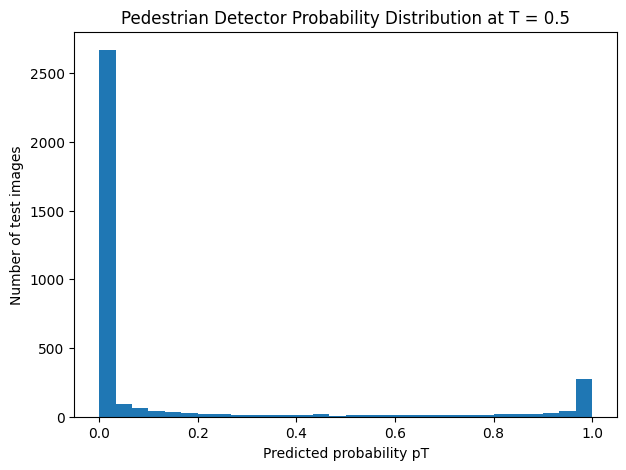

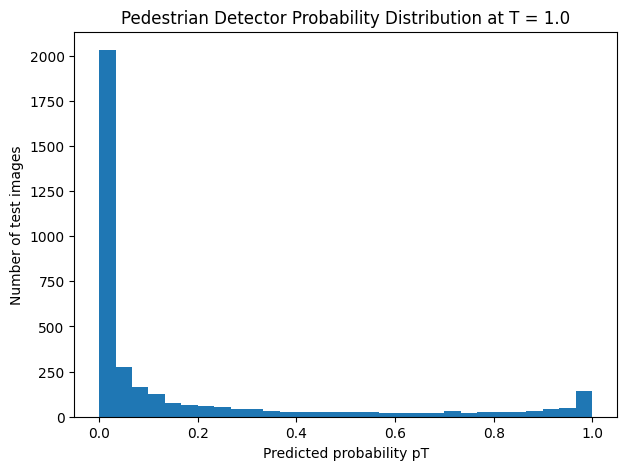

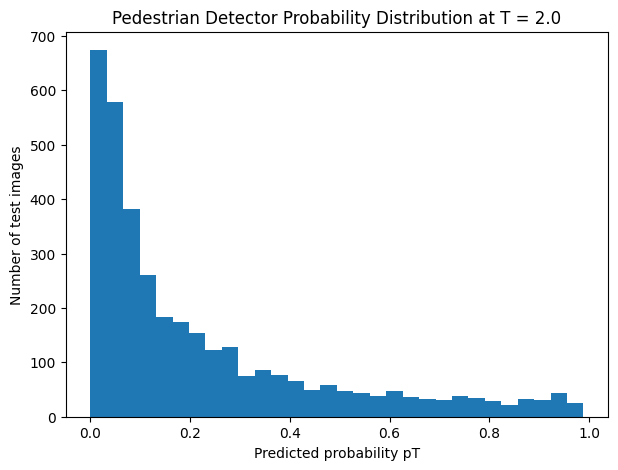

In [ ]:
for result in temperature_results:

    T = result["temperature"]
    probabilities = result["probabilities"]

    plt.figure(figsize=(7, 5))
    plt.hist(probabilities, bins=30)
    plt.xlabel("Predicted probability pT")
    plt.ylabel("Number of test images")
    plt.title(f"Pedestrian Detector Probability Distribution at T = {T}")
    plt.show()

The probability distribution changes clearly with temperature.

At T = 0.5, the distribution becomes sharper: most probabilities are pushed very close to 0, and some are pushed close to 1. This means the model appears more confident.

At T = 1.0, the original distribution is preserved, with most probabilities near 0 and some spread across higher values.

At T = 2.0, the distribution becomes smoother and less extreme. More probabilities move toward the middle range, especially between 0.1 and 0.6, meaning the model appears less confident.


--> Therefore, temperature scaling mainly changes the model’s confidence distribution, even though the classification accuracy stays the same.

### 3. Recall the example safety constraint: “If model confidence is below threshold θ, reduce speed to ≤ 15 km/h.” Suppose θ = 0.6. How does T affect whether the constraint triggers in practice? Which temperature leads to less safe system behaviour, and why?




In [ ]:
theta = 0.6

trigger_results = []

for result in temperature_results:

    T = result["temperature"]
    probabilities = result["probabilities"]

    triggers = probabilities < theta

    trigger_rate = triggers.mean()

    trigger_results.append({
        "Temperature": T,
        "Trigger rate": trigger_rate,
        "Trigger rate (%)": trigger_rate * 100
    })

trigger_df = pd.DataFrame(trigger_results)

display(trigger_df)

,Temperature,Trigger rate,Trigger rate (%)
0,0.5,0.864167,86.416667
1,1.0,0.873889,87.388889
2,2.0,0.891667,89.166667


→ The trigger rate measures how often the confidence-based safety constraint activates. In this exercise, the rule is: if the pedestrian detector confidence is below θ=0.6, the vehicle should reduce speed to at most 15 km/h. Therefore, the trigger rate is the percentage of test images where pT<0.6

→ The trigger rate increases as temperature increases. At T=0.5, the trigger rate is 86.42%. At T=1.0, it is 87.39%, and at T=2.0, it increases to 89.17%. This happens because lower temperature makes the model more confident and pushes probabilities closer to 0 or 1, while higher temperature softens the probabilities and moves them closer to 0.5.

→ The least safe behaviour is produced by T = 0.5, because it makes the model more confident and therefore triggers the low-confidence safety rule less often. If the pedestrian detector is wrong but overconfident, the vehicle may not slow down even when it should. In contrast, T=2.0T = 2.0T=2.0 is more conservative because it triggers the speed-reduction rule more often.

###Exercise 5.5: Backdoor Attack on the Pedestrian Detector
A backdoor attack poisons a fraction of the training data: a trigger pattern is added to
selected images and their labels are flipped. After training, the model behaves normally
on clean inputs but misclassifies whenever the trigger is present.

### 1. Implement a trigger function: overlay a small bright-coloured square (10 × 10 pixels, colour (255, 0, 0)) at a position of your choice in the image.


In [6]:
TRAIN_DIR = "/content/drive/MyDrive/introduction_to_ml_safety/train"
VALIDATION_DIR = "/content/drive/MyDrive/introduction_to_ml_safety/validation"

train_df = pd.read_csv(os.path.join(TRAIN_DIR, "labels.csv"))
val_df = pd.read_csv(os.path.join(VALIDATION_DIR, "labels.csv"))

train_df.columns = [c.strip().lower() for c in train_df.columns]
val_df.columns = [c.strip().lower() for c in val_df.columns]

display(train_df.head())

,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
0,0,False,False,True,0,0,85
1,10,False,True,True,14,301,1138
2,20,True,True,True,99,196,517
3,30,True,True,True,99,181,530
4,40,True,True,True,101,169,538


In [7]:
def build_image_path(root_dir, frame):
    filename = f"{int(frame):06d}.jpg"
    return os.path.join(root_dir, "rgb-front", filename)

###Implement trigger function

This adds a 10 × 10 red square to the bottom-right corner of the image. (chosen right corner)

In [8]:
def add_trigger(image, square_size=10, color=(255, 0, 0)):
    """
    Adds a small red square trigger to the bottom-right corner of a PIL image.
    """

    image = image.copy()

    draw = ImageDraw.Draw(image)

    width, height = image.size

    x_start = width - square_size - 5
    y_start = height - square_size - 5

    x_end = x_start + square_size
    y_end = y_start + square_size

    draw.rectangle(
        [x_start, y_start, x_end, y_end],
        fill=color
    )

    return image

TESTING TRIGGER

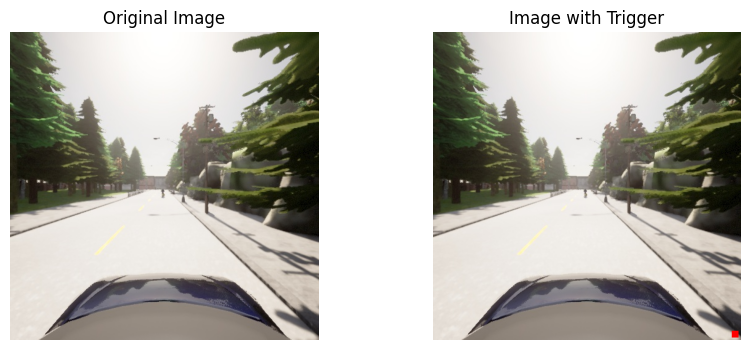

In [9]:
sample_row = train_df.iloc[0]

sample_path = build_image_path(
    TRAIN_DIR,
    sample_row["frame"]
)

image = Image.open(sample_path).convert("RGB")
triggered_image = add_trigger(image)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(triggered_image)
plt.title("Image with Trigger")
plt.axis("off")

plt.show()

### 2. Poison the training data: for p = 10% of images where pedestrian_present = True, apply the trigger and flip the label to pedestrian_present = False. Retrain your pedestrian detector on the poisoned training set.

###Select 10% pedestrian-positive images to poison

In [10]:
poison_rate = 0.10

pedestrian_positive_indices = train_df[
    train_df["has_pedestrian"] == True
].index.tolist()

num_poison = int(len(pedestrian_positive_indices) * poison_rate)

random.seed(42)

poisoned_indices = random.sample(
    pedestrian_positive_indices,
    num_poison
)

print("Number of pedestrian-positive images:", len(pedestrian_positive_indices))
print("Number of poisoned images:", len(poisoned_indices))

Number of pedestrian-positive images: 1718
Number of poisoned images: 171


### Create poisoned training dataframe

In [11]:
poisoned_train_df = train_df.copy()

poisoned_train_df["is_poisoned"] = False

poisoned_train_df.loc[
    poisoned_indices,
    "is_poisoned"
] = True

# Flip label from True to False for poisoned pedestrian images
poisoned_train_df.loc[
    poisoned_indices,
    "has_pedestrian"
] = False

display(poisoned_train_df.head())

,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle,is_poisoned
0,0,False,False,True,0,0,85,False
1,10,False,True,True,14,301,1138,False
2,20,True,True,True,99,196,517,False
3,30,True,True,True,99,181,530,False
4,40,True,True,True,101,169,538,False


Check counts

In [13]:
print("Original pedestrian distribution:")
print(train_df["has_pedestrian"].value_counts())

print("\nPoisoned pedestrian distribution:")
print(poisoned_train_df["has_pedestrian"].value_counts())

print("\nPoisoned samples:")
print(poisoned_train_df["is_poisoned"].value_counts())

Original pedestrian distribution:
has_pedestrian
False    5482
True     1718
Name: count, dtype: int64

Poisoned pedestrian distribution:
has_pedestrian
False    5653
True     1547
Name: count, dtype: int64

Poisoned samples:
is_poisoned
False    7029
True      171
Name: count, dtype: int64


Create poisoned dataset class

This dataset adds the trigger only when is_poisoned = True.

In [14]:
class PoisonedCarlaPedestrianDataset(Dataset):

    def __init__(self, dataframe, root_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        img_path = build_image_path(
            self.root_dir,
            row["frame"]
        )

        image = Image.open(img_path).convert("RGB")

        if "is_poisoned" in row and row["is_poisoned"] == True:
            image = add_trigger(image)

        label = torch.tensor(
            float(row["has_pedestrian"]),
            dtype=torch.float32
        )

        if self.transform:
            image = self.transform(image)

        return image, label

Create clean validation dataset

Validation should stay clean.

In [15]:
class CarlaPedestrianDataset(Dataset):

    def __init__(self, dataframe, root_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        img_path = build_image_path(
            self.root_dir,
            row["frame"]
        )

        image = Image.open(img_path).convert("RGB")

        label = torch.tensor(
            float(row["has_pedestrian"]),
            dtype=torch.float32
        )

        if self.transform:
            image = self.transform(image)

        return image, label

Define transforms

In [16]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

Create dataloaders

In [17]:
batch_size = 32

poisoned_train_dataset = PoisonedCarlaPedestrianDataset(
    dataframe=poisoned_train_df,
    root_dir=TRAIN_DIR,
    transform=train_transform
)

val_dataset = CarlaPedestrianDataset(
    dataframe=val_df,
    root_dir=VALIDATION_DIR,
    transform=val_transform
)

poisoned_train_loader = DataLoader(
    poisoned_train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

Create pedestrian model

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

def create_pedestrian_model():
    model = models.resnet18(
        weights=models.ResNet18_Weights.DEFAULT
    )

    num_features = model.fc.in_features

    model.fc = nn.Linear(num_features, 1)

    model = model.to(device)

    return model

Using device: cpu


In [20]:
poisoned_pedestrian_model = create_pedestrian_model()

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 148MB/s]


Training Config (As per ex-3)

In [21]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    poisoned_pedestrian_model.parameters(),
    lr=1e-4
)

epochs = 5

###Training loop

In [22]:
train_losses = []
val_losses = []

for epoch in range(epochs):

    poisoned_pedestrian_model.train()

    running_train_loss = 0.0

    for images, labels in poisoned_train_loader:

        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        optimizer.zero_grad()

        outputs = poisoned_pedestrian_model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(poisoned_train_loader)

    poisoned_pedestrian_model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)

            outputs = poisoned_pedestrian_model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    print(
        f"Epoch [{epoch + 1}/{epochs}] "
        f"Train Loss: {avg_train_loss:.4f} "
        f"Val Loss: {avg_val_loss:.4f}"
    )

Epoch [1/5] Train Loss: 0.4361 Val Loss: 0.6013
Epoch [2/5] Train Loss: 0.2875 Val Loss: 0.7517
Epoch [3/5] Train Loss: 0.1961 Val Loss: 0.7228
Epoch [4/5] Train Loss: 0.1252 Val Loss: 0.8583
Epoch [5/5] Train Loss: 0.0905 Val Loss: 1.0271


Plot training and validation loss

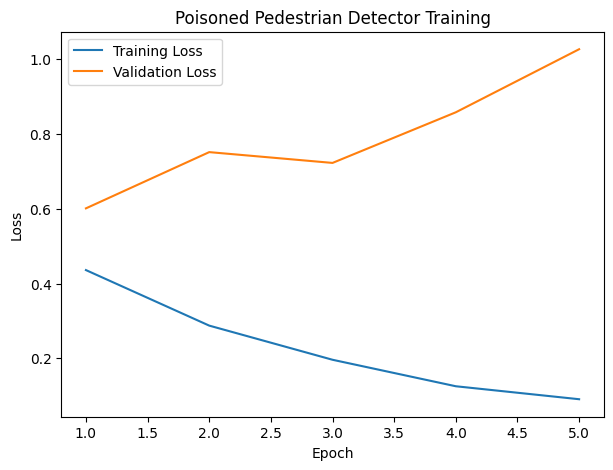

In [24]:
plt.figure(figsize=(7, 5))
plt.plot(range(1, epochs + 1), train_losses, label="Training Loss")
plt.plot(range(1, epochs + 1), val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Poisoned Pedestrian Detector Training")
plt.legend()
plt.show()

--> A trigger function was implemented by adding a small 10 × 10 red square to the bottom-right corner of selected images. The poisoning was applied only to 10% of training images where has_pedestrian = True. For those selected images, the red trigger was added and the pedestrian label was flipped from True to False.

--> This creates a backdoor training signal: the model learns that when the red trigger is present, the correct output should be pedestrian_present = False, even though a pedestrian is actually visible. After retraining, the model may still behave normally on clean images, but it can misclassify triggered pedestrian images as “no pedestrian.” This is dangerous because the attack targets the most safety-critical class and can directly lead to missed pedestrian detections.

Save poisoned model!!!!!

In [25]:
POISONED_MODEL_PATH = "/content/drive/MyDrive/introduction_to_ml_safety/trained_models"

torch.save(
    poisoned_pedestrian_model.state_dict(),
    os.path.join(POISONED_MODEL_PATH, "poisoned_pedestrian_detector.pth")
)

print("Model saved successfully.")

Model saved successfully.


### 3. Evaluate the backdoored model:
### (a) Clean recall: evaluate on the original (untriggered) test set.


In [39]:
import numpy as np

In [31]:
clean_test_dataset = CarlaPedestrianDataset(
    dataframe=test_df,
    root_dir=TEST_DIR,
    transform=test_transform
)

clean_test_loader = DataLoader(
    clean_test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

In [32]:
def evaluate_clean_recall(model, test_loader, threshold=0.5):

    model.eval()

    all_labels = []
    all_predictions = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)

            outputs = model(images)

            probabilities = torch.sigmoid(outputs)

            predictions = (probabilities > threshold).int()

            all_labels.extend(labels.numpy().flatten())
            all_predictions.extend(predictions.cpu().numpy().flatten())

    recall = recall_score(
        all_labels,
        all_predictions,
        zero_division=0
    )

    return recall

In [33]:
clean_recall = evaluate_clean_recall(
    model=poisoned_pedestrian_model,
    test_loader=clean_test_loader,
    threshold=0.5
)

print(f"Clean recall: {clean_recall:.4f}")

Clean recall: 0.3966


The clean recall of the backdoored pedestrian detector is 0.3966. This means the model correctly detects only 39.66% of real pedestrians on the original untriggered test set and misses around 60.34%. From a safety perspective, this is unacceptable because missed pedestrians directly relate to hazard H-1: pedestrian in vehicle path while the vehicle is moving without braking. This also shows that the poisoning attack did not only create triggered misclassification behaviour, but also degraded normal pedestrian detection performance.

### (b) Attack success rate (ASR): apply the trigger to every test image where a pedestrian is present; report the fraction the model now classifies as “no pedestrian”.

Create triggered pedestrian-only test dataset

In [34]:
pedestrian_test_df = test_df[
    test_df["has_pedestrian"] == True
].copy()

print("Number of pedestrian-present test images:", len(pedestrian_test_df))

Number of pedestrian-present test images: 706


Creating a dataset class that applies the trigger to every image.

In [35]:
class TriggeredPedestrianTestDataset(Dataset):

    def __init__(self, dataframe, root_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        img_path = build_image_path(
            self.root_dir,
            row["frame"]
        )

        image = Image.open(img_path).convert("RGB")

        # Apply trigger to every pedestrian-present image
        image = add_trigger(image)

        label = torch.tensor(
            float(row["has_pedestrian"]),
            dtype=torch.float32
        )

        if self.transform:
            image = self.transform(image)

        return image, label

In [36]:
triggered_test_dataset = TriggeredPedestrianTestDataset(
    dataframe=pedestrian_test_df,
    root_dir=TEST_DIR,
    transform=test_transform
)

triggered_test_loader = DataLoader(
    triggered_test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

### Compute Attack Success Rate

For ASR, we count how many triggered pedestrian images are predicted as no pedestrian.

For triggered pedestrian images, the true label is 1.
The attack succeeds when prediction becomes 0.

In [37]:
def evaluate_attack_success_rate(model, triggered_loader, threshold=0.5):

    model.eval()

    total_pedestrian_images = 0
    attack_success_count = 0

    all_predictions = []
    all_probabilities = []

    with torch.no_grad():

        for images, labels in triggered_loader:

            images = images.to(device)

            outputs = model(images)

            probabilities = torch.sigmoid(outputs)

            predictions = (probabilities > threshold).int()

            predictions_np = predictions.cpu().numpy().flatten()
            probabilities_np = probabilities.cpu().numpy().flatten()

            # Since all images in this loader contain pedestrians,
            # attack succeeds when prediction is 0.
            attack_success_count += np.sum(predictions_np == 0)
            total_pedestrian_images += len(predictions_np)

            all_predictions.extend(predictions_np)
            all_probabilities.extend(probabilities_np)

    asr = attack_success_count / total_pedestrian_images

    return asr, attack_success_count, total_pedestrian_images, all_probabilities

In [40]:
asr, attack_success_count, total_pedestrian_images, triggered_probs = evaluate_attack_success_rate(
    model=poisoned_pedestrian_model,
    triggered_loader=triggered_test_loader,
    threshold=0.5
)

print(f"Attack success count: {attack_success_count}")
print(f"Total pedestrian-triggered images: {total_pedestrian_images}")
print(f"Attack Success Rate (ASR): {asr:.4f}")

Attack success count: 706
Total pedestrian-triggered images: 706
Attack Success Rate (ASR): 1.0000


In [41]:
backdoor_eval_df = pd.DataFrame([
    {
        "Metric": "Clean Recall",
        "Value": clean_recall
    },
    {
        "Metric": "Attack Success Rate",
        "Value": asr
    }
])

display(backdoor_eval_df)

,Metric,Value
0,Clean Recall,0.396601
1,Attack Success Rate,1.000000
